# CDR Forcing Creation

This notebook prepares and assembles carbon dioxide removal (CDR)-related forcing inputs used by the model workflow, including preprocessing and export-ready forcing products.

## Setup and Core Imports

This section imports the ROMS tools used for grid access, CDR forcing construction, and volume-release definitions, then defines shared project paths and model identifiers.

In [136]:
from roms_tools import Grid
import xarray as xr

In [137]:
from roms_tools import VolumeRelease
from datetime import datetime

In [138]:
project_path = '/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/'
datasets_path = '/anvil/projects/x-ees250129/Datasets/'
model_name = 'Iceland3'
grid_path = project_path + 'Iceland3_grid.nc'

partition_output_paths = {
    'ENS1': '/home/x-uheede/S/Iceland3_MARBL_2024_CDR1/P_INPUT',
    'ENS2': '/home/x-uheede/S/Iceland3_MARBL_2024_CDR2/P_INPUT',
    'ENS3': '/home/x-uheede/S/Iceland3_MARBL_2024_CDR3/P_INPUT',
    'ENS4': '/home/x-uheede/S/Iceland3_MARBL_2024_CDR4/P_INPUT',
    'ENS5': '/home/x-uheede/S/Iceland3_MARBL_2024_CDR5/P_INPUT',
    'ENS6': '/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT',
}

In [139]:
grid = Grid.from_file(grid_path)

## Ensemble 1 Configuration and Build

This section defines the first release schedule and source settings, builds the first CDR forcing object, generates quick diagnostic plots, and saves `ENS1` to disk.

In [140]:
times = [
    datetime(2024, 7, 9, 0, 0),
    datetime(2024, 7, 10, 0, 0),
    datetime(2024, 7, 11, 0, 0),
    datetime(2024, 7, 12, 0, 0),
    datetime(2024, 7, 13, 0, 0),
    datetime(2024, 7, 14, 0, 0),
    datetime(2024, 7, 15, 0, 0),
    datetime(2024, 7, 16, 0, 0),
    datetime(2024, 7, 17, 0, 0),
    datetime(2024, 7, 18, 0, 0),
    datetime(2024, 7, 19, 0, 0),
    datetime(2024, 7, 20, 0, 0),
]

In [141]:
constant_volume_release_iceland = VolumeRelease(
    name="iceland_release",
    lat=64.394213,  # degree N
    lon=-21.465904,  # degree E
    depth=2,  # m
    times=times,
    volume_fluxes=[0,0,0,0.0005,0.0005,0.0005,0.0005,0,0,0,0,0],  # m3/s
    tracer_concentrations={
        "temp": 10.0,  # degrees C±±
        "salt": 1.0,  # psu
        "ALK": 1180000  # meq/m3
        },
    fill_values="zero"
)

In [142]:
from roms_tools import CDRForcing

In [143]:
start_time_release = datetime(2024, 7, 9)
end_time_release = datetime(2024, 7, 20)

In [144]:
cdr_forcing_with_volume_releases1 = CDRForcing(
    grid=grid,
    start_time=start_time_release,
    end_time=end_time_release,
    model_reference_date=datetime(2000, 1, 1), # this is the default
    releases=[
        constant_volume_release_iceland],
)

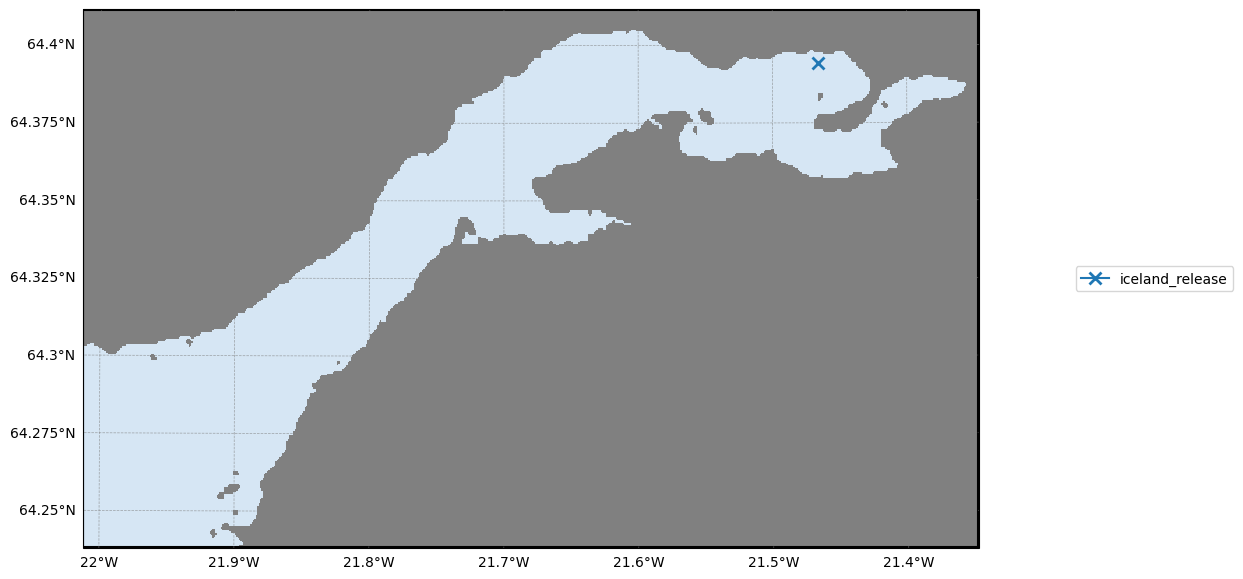

In [145]:
cdr_forcing_with_volume_releases1.plot_locations()  # By default, this plots all available releases (but max 20).




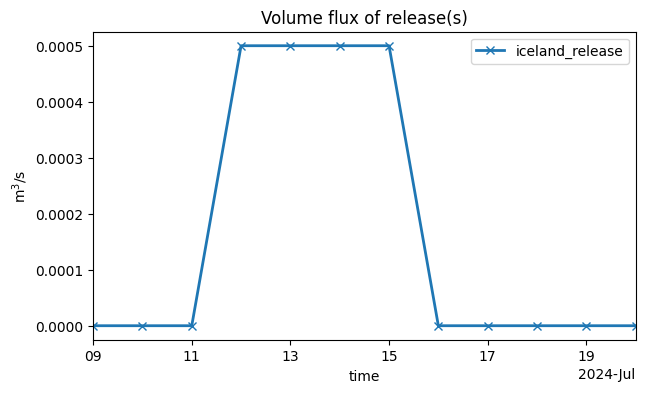

In [146]:
cdr_forcing_with_volume_releases1.plot_volume_flux()

In [147]:
filepath1 = project_path + model_name + '_cdr_forcing_ENS1.nc'

In [148]:
cdr_forcing_with_volume_releases1.save(filepath=filepath1)

2026-04-08 13:04:30 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_cdr_forcing_ENS1.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_cdr_forcing_ENS1.nc')]

## Ensemble 2 Configuration and Build

This section updates timing and release settings for ensemble 2, rebuilds the forcing object with the new scenario, and writes the `ENS2` forcing file.

In [149]:
times = [
    datetime(2024, 7, 11, 0, 0),
    datetime(2024, 7, 12, 0, 0),
    datetime(2024, 7, 13, 0, 0),
    datetime(2024, 7, 14, 0, 0),
    datetime(2024, 7, 15, 0, 0),
    datetime(2024, 7, 16, 0, 0),
    datetime(2024, 7, 17, 0, 0),
    datetime(2024, 7, 18, 0, 0),
    datetime(2024, 7, 19, 0, 0),
    datetime(2024, 7, 20, 0, 0),
    datetime(2024, 7, 21, 0, 0),
    datetime(2024, 7, 22, 0, 0),
]

In [150]:
constant_volume_release_iceland = VolumeRelease(
    name="iceland_release",
    lat=64.394213,  # degree N
    lon=-21.465904,  # degree E
    depth=2,  # m
    times=times,
    volume_fluxes=[0,0,0,0.0005,0.0005,0.0005,0.0005,0,0,0,0,0],  # m3/s
    tracer_concentrations={
        "temp": 10.0,  # degrees C±±
        "salt": 1.0,  # psu
        "ALK": 1180000  # meq/m3
        },
    fill_values="zero"
)

In [151]:
from roms_tools import CDRForcing

In [152]:
start_time_release = datetime(2024, 7, 11)
end_time_release = datetime(2024, 7, 22)

In [153]:
cdr_forcing_with_volume_releases2 = CDRForcing(
    grid=grid,
    start_time=start_time_release,
    end_time=end_time_release,
    model_reference_date=datetime(2000, 1, 1), # this is the default
    releases=[
        constant_volume_release_iceland],
)

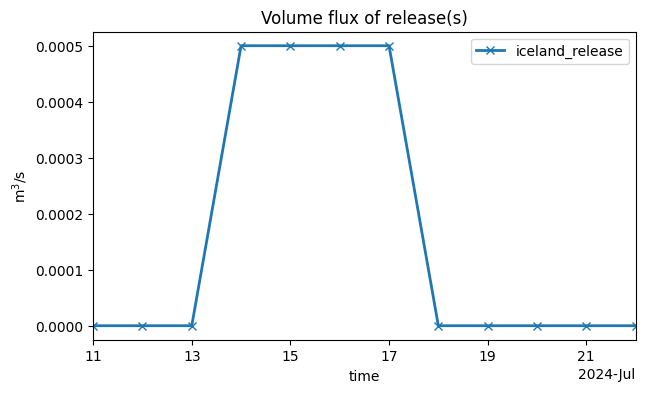

In [154]:
cdr_forcing_with_volume_releases2.plot_volume_flux()

In [155]:
filepath2 = project_path + model_name + '_cdr_forcing_ENS2.nc'
cdr_forcing_with_volume_releases2.save(filepath=filepath2)

2026-04-08 13:04:30 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_cdr_forcing_ENS2.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_cdr_forcing_ENS2.nc')]

## Ensemble 3 Configuration and Build

This section repeats the forcing-generation workflow for ensemble 3 using its own release timing, then saves the resulting `ENS3` NetCDF output.

In [156]:
times = [
    datetime(2024, 7, 13, 0, 0),
    datetime(2024, 7, 14, 0, 0),
    datetime(2024, 7, 15, 0, 0),
    datetime(2024, 7, 16, 0, 0),
    datetime(2024, 7, 17, 0, 0),
    datetime(2024, 7, 18, 0, 0),
    datetime(2024, 7, 19, 0, 0),
    datetime(2024, 7, 20, 0, 0),
    datetime(2024, 7, 21, 0, 0),
    datetime(2024, 7, 22, 0, 0),
    datetime(2024, 7, 23, 0, 0),
    datetime(2024, 7, 24, 0, 0),
]

In [157]:
constant_volume_release_iceland = VolumeRelease(
    name="iceland_release",
    lat=64.394213,  # degree N
    lon=-21.465904,  # degree E
    depth=2,  # m
    times=times,
    volume_fluxes=[0,0,0,0.0005,0.0005,0.0005,0.0005,0,0,0,0,0],  # m3/s
    tracer_concentrations={
        "temp": 10.0,  # degrees C±±
        "salt": 1.0,  # psu
        "ALK": 1180000  # meq/m3
        },
    fill_values="zero"
)

In [158]:
start_time_release = datetime(2024, 7, 13)
end_time_release = datetime(2024, 7, 24)

In [159]:
cdr_forcing_with_volume_releases3 = CDRForcing(
    grid=grid,
    start_time=start_time_release,
    end_time=end_time_release,
    model_reference_date=datetime(2000, 1, 1), # this is the default
    releases=[
        constant_volume_release_iceland],
)

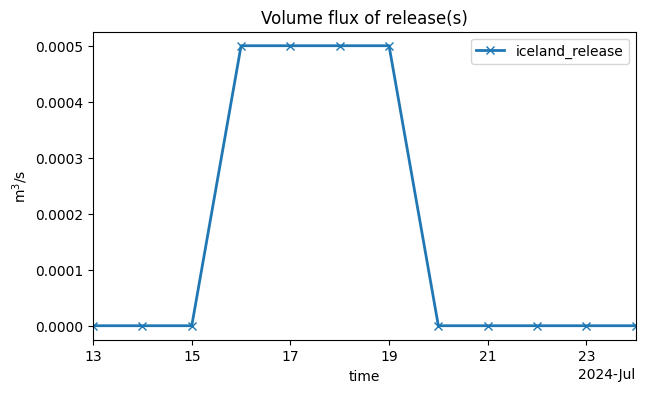

In [160]:
cdr_forcing_with_volume_releases3.plot_volume_flux()

In [161]:
filepath3 = project_path + model_name + '_cdr_forcing_ENS3.nc'
cdr_forcing_with_volume_releases3.save(filepath=filepath3)

2026-04-08 13:04:30 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_cdr_forcing_ENS3.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_cdr_forcing_ENS3.nc')]

## Ensembles 4-6 Configuration and Build

This section constructs the release scenarios for ensembles 4, 5, and 6, builds and inspects each forcing signal, and saves the corresponding forcing files.

In [162]:
times4 = [
    datetime(2024, 11, 2, 0, 0),
    datetime(2024, 11, 3, 0, 0),
    datetime(2024, 11, 4, 0, 0),
    datetime(2024, 11, 5, 0, 0),
    datetime(2024, 11, 6, 0, 0),
    datetime(2024, 11, 7, 0, 0),
    datetime(2024, 11, 8, 0, 0),
    datetime(2024, 11, 9, 0, 0),
    datetime(2024, 11, 10, 0, 0),
    datetime(2024, 11, 11, 0, 0),
    datetime(2024, 11, 12, 0, 0),
    datetime(2024, 11, 13, 0, 0),
]

times5 = [
    datetime(2024, 11, 6, 6, 0),
    datetime(2024, 11, 7, 6, 0),
    datetime(2024, 11, 8, 6, 0),
    datetime(2024, 11, 9, 6, 0),
    datetime(2024, 11, 10, 6, 0),
    datetime(2024, 11, 11, 6, 0),
    datetime(2024, 11, 12, 6, 0),
    datetime(2024, 11, 13, 6, 0),
    datetime(2024, 11, 14, 6, 0),
    datetime(2024, 11, 15, 6, 0),
    datetime(2024, 11, 16, 6, 0),
    datetime(2024, 11, 17, 0, 0),
]

times6 = [
    datetime(2024, 11, 14, 0, 0),
    datetime(2024, 11, 15, 0, 0),
    datetime(2024, 11, 16, 0, 0),
    datetime(2024, 11, 17, 0, 0),
    datetime(2024, 11, 18, 0, 0),
    datetime(2024, 11, 19, 0, 0),
    datetime(2024, 11, 20, 0, 0),
    datetime(2024, 11, 21, 0, 0),
    datetime(2024, 11, 22, 0, 0),
    datetime(2024, 11, 23, 0, 0),
    datetime(2024, 11, 24, 0, 0),
    datetime(2024, 11, 25, 0, 0),
]

In [163]:
start_time_release4 = datetime(2024, 11, 2)
end_time_release4 = datetime(2024, 11, 13)

start_time_release5 = datetime(2024, 11, 6)
end_time_release5 = datetime(2024, 11, 17)

start_time_release6 = datetime(2024, 11, 14)
end_time_release6 = datetime(2024, 11, 25)

In [164]:
constant_volume_release_iceland4 = VolumeRelease(
    name="iceland_release",
    lat=64.394213,  # degree N
    lon=-21.465904,  # degree E
    depth=2,  # m
    times=times4,
    volume_fluxes=[0,0,0,0.0005,0.0005,0.0005,0.0005,0,0,0,0,0],  # m3/s
    tracer_concentrations={
        "temp": 10.0,  # degrees C±±
        "salt": 1.0,  # psu
        "ALK": 1180000  # meq/m3
        },
    fill_values="zero"
)

constant_volume_release_iceland5 = VolumeRelease(
    name="iceland_release",
    lat=64.394213,  # degree N
    lon=-21.465904,  # degree E
    depth=2,  # m
    times=times5,
    volume_fluxes=[0,0,0,0.0005,0.0005,0.0005,0.0005,0,0,0,0,0],  # m3/s
    tracer_concentrations={
        "temp": 10.0,  # degrees C±±
        "salt": 1.0,  # psu
        "ALK": 1180000  # meq/m3
        },
    fill_values="zero"
)

constant_volume_release_iceland6 = VolumeRelease(
    name="iceland_release",
    lat=64.394213,  # degree N
    lon=-21.465904,  # degree E
    depth=2,  # m
    times=times6,
    volume_fluxes=[0,0,0,0.0005,0.0005,0.0005,0.0005,0,0,0,0,0],  # m3/s
    tracer_concentrations={
        "temp": 10.0,  # degrees C±±
        "salt": 1.0,  # psu
        "ALK": 1180000  # meq/m3
        },
    fill_values="zero"
)

In [165]:
cdr_forcing_with_volume_releases4 = CDRForcing(
    grid=grid,
    start_time=start_time_release4,
    end_time=end_time_release4,
    model_reference_date=datetime(2000, 1, 1), # this is the default
    releases=[
        constant_volume_release_iceland4],
)

cdr_forcing_with_volume_releases5 = CDRForcing(
    grid=grid,
    start_time=start_time_release5,
    end_time=end_time_release5,
    model_reference_date=datetime(2000, 1, 1), # this is the default
    releases=[
        constant_volume_release_iceland5],
)

cdr_forcing_with_volume_releases6 = CDRForcing(
    grid=grid,
    start_time=start_time_release6,
    end_time=end_time_release6,
    model_reference_date=datetime(2000, 1, 1), # this is the default
    releases=[
        constant_volume_release_iceland6],
)

In [166]:
filepath4 = project_path + model_name + '_cdr_forcing_ENS4.nc'
cdr_forcing_with_volume_releases4.save(filepath=filepath4)

filepath5 = project_path + model_name + '_cdr_forcing_ENS5.nc'
cdr_forcing_with_volume_releases5.save(filepath=filepath5)

filepath6 = project_path + model_name + '_cdr_forcing_ENS6.nc'
cdr_forcing_with_volume_releases6.save(filepath=filepath6)

2026-04-08 13:04:30 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_cdr_forcing_ENS4.nc
2026-04-08 13:04:30 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_cdr_forcing_ENS5.nc
2026-04-08 13:04:30 - INFO - Writing the following NetCDF files:
/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_cdr_forcing_ENS6.nc


[PosixPath('/anvil/projects/x-ees250129/x-uheede/INPUT_files/Iceland3_MARBL_2024/Iceland3_cdr_forcing_ENS6.nc')]

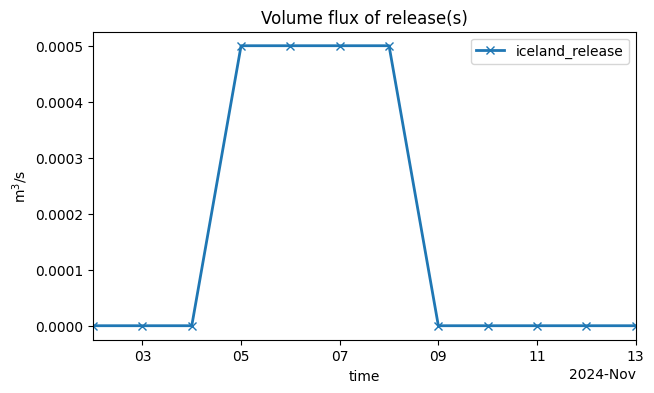

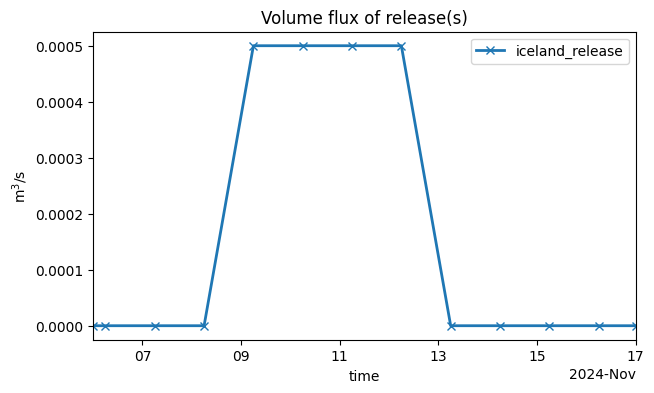

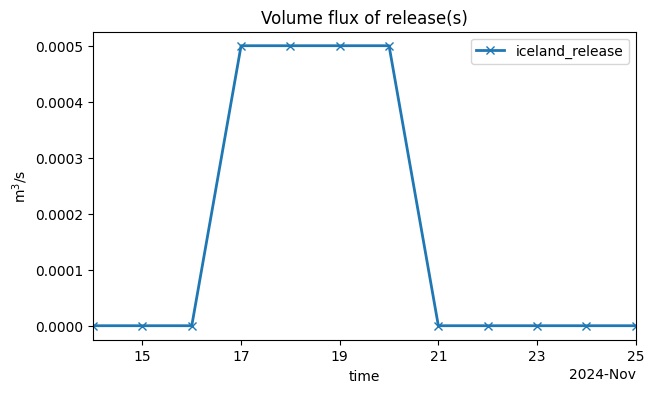

In [167]:
cdr_forcing_with_volume_releases4.plot_volume_flux()
cdr_forcing_with_volume_releases5.plot_volume_flux()
cdr_forcing_with_volume_releases6.plot_volume_flux()

## Optional Partitioning and Post-processing

This section provides optional utilities for partitioning generated NetCDF forcing files for downstream model execution workflows.

In [169]:
from roms_tools import partition_netcdf
partition_netcdf(filepath1, 16, 16, partition_output_paths['ENS1'])
partition_netcdf(filepath2, 16, 16, partition_output_paths['ENS2'])
partition_netcdf(filepath3, 16, 16, partition_output_paths['ENS3'])

partition_netcdf(filepath4, 16, 16, partition_output_paths['ENS4'])
partition_netcdf(filepath5, 16, 16, partition_output_paths['ENS5'])
partition_netcdf(filepath6, 16, 16, partition_output_paths['ENS6'])

[PosixPath('/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT/Iceland3_cdr_forcing_ENS6.000.nc'),
 PosixPath('/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT/Iceland3_cdr_forcing_ENS6.001.nc'),
 PosixPath('/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT/Iceland3_cdr_forcing_ENS6.002.nc'),
 PosixPath('/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT/Iceland3_cdr_forcing_ENS6.003.nc'),
 PosixPath('/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT/Iceland3_cdr_forcing_ENS6.004.nc'),
 PosixPath('/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT/Iceland3_cdr_forcing_ENS6.005.nc'),
 PosixPath('/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT/Iceland3_cdr_forcing_ENS6.006.nc'),
 PosixPath('/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT/Iceland3_cdr_forcing_ENS6.007.nc'),
 PosixPath('/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT/Iceland3_cdr_forcing_ENS6.008.nc'),
 PosixPath('/home/x-uheede/S/Iceland3_MARBL_2024_CDR6/P_INPUT/Iceland3_cdr_forcing_ENS6.009.nc'),
 PosixPath('/home/x-